一つの加工対象csvファイルに対して、そのデータ数を設定した数まで圧縮するコード

えぬグラフでグラフ化しやすいようにデータの圧縮を行うだけなので、特徴量の抽出は行わあない。

In [1]:
# セル1: ライブラリのインポート
import tkinter as tk
from tkinter import filedialog
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re

# グラフの日本語文字化け防止
plt.rcParams['font.family'] = ['Times New Roman', 'MS Gothic']

print("セル1: ライブラリのインポートと設定が完了しました。")

セル1: ライブラリのインポートと設定が完了しました。


In [2]:
# セル2: 設定セクション
ROWS_TO_SKIP = 70
FILE_ENCODING = 'cp932'
TARGET_COLUMN = '(1)HA-V05'

# 平滑化の強さ（数値を大きくすると線がより滑らかになります）
SMOOTHING_FACTOR = 2.0 

# 理想の出力行数（Excelで重くならない目標行数）
TARGET_ROW_COUNT = 10000 

# ==========================================
# ★ 切り出す時間範囲の指定（秒）
# ==========================================
# CLIP_MODE = 'auto'  : 立ち上がり（平滑化後の電圧が RISE_THRESHOLD_V を初めて超えた時刻）を自動で探し、
#                       その BEFORE_RISE_SEC 秒前から AFTER_RISE_SEC 秒後までを切り出します。
# CLIP_MODE = 'fixed' : 下の START_TIME_SEC〜END_TIME_SEC を切り出します。
CLIP_MODE = 'auto'
RISE_THRESHOLD_V = 2.0   # 立ち上がりと判定する電圧 [V]
BEFORE_RISE_SEC = 2.0    # 立ち上がりの何秒前から切り出すか
AFTER_RISE_SEC = 2.0     # 立ち上がりの何秒後まで切り出すか

# 'fixed' のとき（または立ち上がりが見つからないとき）に使う範囲です。
# 抽出を開始・終了する時間を「秒」で入力します。
# 制限しない（最初から最後までにする）場合は None にしてください。
START_TIME_SEC = 0.0     # 例: 0.0秒から開始
END_TIME_SEC = 4.0      # 例: 4.0秒で終了（最後まで抽出する場合は None）

PLOT_ORIGINAL = True  # グラフに元の波形（薄いグレー）も描画するかどうか

print("セル2: 設定の読み込みが完了しました。")

セル2: 設定の読み込みが完了しました。


In [3]:
# セル3: ファイル選択
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)

print("ファイル選択ダイアログを開いています...（画面の裏に隠れている場合があります）")
filepath = filedialog.askopenfilename(
    title="解析したいCSVファイル（1つ）を選択してください",
    filetypes=[("CSV files", "*.csv"), ("All files", "*.*")]
)

if not filepath:
    print("キャンセルされました。")
else:
    print(f"選択されたファイル: {filepath}")

ファイル選択ダイアログを開いています...（画面の裏に隠れている場合があります）
選択されたファイル: C:/Users/0uh2j/OneDrive/Desktop/実験データ2026/本実験データ/202606_本実験温度データ/csv/0.5-2.0mmデータ/1.0mm/210℃/035_210℃_080_1.0mm.csv


In [4]:
# セル4: データ処理（全データでの計算 -> 時間切り出し -> 間引き）
if not 'filepath' in locals() or not filepath:
    print("エラー: セル3でファイルを選択してください。")
else:
    # サンプリング周期の読み取り
    actual_sampling_rate_hz = 100000.0  
    try:
        with open(filepath, 'r', encoding=FILE_ENCODING, errors='ignore') as f:
            for _ in range(50):
                line = f.readline()
                if not line: break
                if 'サンプリング周期' in line:
                    match = re.search(r'(\d+)\s*μs', line)
                    if match:
                        us_val = float(match.group(1))
                        if us_val > 0:
                            actual_sampling_rate_hz = 1000000.0 / us_val
                            break
    except Exception as e:
        print(f" -> [警告] ヘッダー読み取りエラー: {e}")

    print("全データを読み込んでいます（数秒〜数十秒かかります）...")
    try:
        df = pd.read_csv(
            filepath, 
            skiprows=ROWS_TO_SKIP, 
            encoding=FILE_ENCODING, 
            encoding_errors='ignore', 
            on_bad_lines='skip', 
            nrows=None, # 全データを一括で読み込み
            low_memory=False
        )
        # ファイル末尾のマーク情報（#BeginMark・#EndMark の行）はデータではないので取り除く
        df = df[~df.iloc[:, 0].astype(str).str.startswith('#')].reset_index(drop=True)
        
        if TARGET_COLUMN not in df.columns:
            print(f" -> [エラー] 列 '{TARGET_COLUMN}' が見つかりません。")
        else:
            df[TARGET_COLUMN] = pd.to_numeric(df[TARGET_COLUMN], errors='coerce').fillna(0)
            
            # ----------------------------------------------------
            # ① すべてのデータ行分（400万行）で時間列を作成
            # ----------------------------------------------------
            print(f"全 {len(df):,} 行に対して時間列を作成中...")
            df['Time (s)'] = np.arange(0, len(df)) * (1.0 / actual_sampling_rate_hz)
            
            # 全データに基づいた間引きステップ数とウィンドウサイズの仮計算
            # （切り抜き境界の歪みを防ぐため、全データ用の最適な窓サイズを割り出します）
            temp_step = max(1, len(df) // TARGET_ROW_COUNT)
            WINDOW_SIZE = int(temp_step * SMOOTHING_FACTOR)
            if WINDOW_SIZE % 2 == 0:
                WINDOW_SIZE += 1
            WINDOW_SIZE = max(3, WINDOW_SIZE)
            
            # ----------------------------------------------------
            # ② すべてのデータ行分（400万行）で先に隣接平均を計算
            # ----------------------------------------------------
            print(f"全データに対して隣接平均を計算中（ウィンドウサイズ: {WINDOW_SIZE} 点）...")
            smoothed_col_name = f'{TARGET_COLUMN}_smoothed'
            df[smoothed_col_name] = df[TARGET_COLUMN].rolling(window=WINDOW_SIZE, center=True, min_periods=1).mean()
            
            # ----------------------------------------------------
            # ③ セル2で設定された時間部分を切り抜く
            # ----------------------------------------------------
            start_t = START_TIME_SEC if START_TIME_SEC is not None else df['Time (s)'].min()
            end_t = END_TIME_SEC if END_TIME_SEC is not None else df['Time (s)'].max()
            
            if CLIP_MODE == 'auto':
                # 平滑化後の電圧が初めて RISE_THRESHOLD_V 以上になった時刻を立ち上がりとし、その前後を切り抜く
                rise_rows = df.index[df[smoothed_col_name] >= RISE_THRESHOLD_V]
                if len(rise_rows) > 0:
                    rise_t = df.loc[rise_rows[0], 'Time (s)']
                    start_t = round(float(max(df['Time (s)'].min(), rise_t - BEFORE_RISE_SEC)), 3)
                    end_t = round(float(min(df['Time (s)'].max(), rise_t + AFTER_RISE_SEC)), 3)
                    print(f"立ち上がりを {rise_t:.3f}s に検出しました。")
                else:
                    print(f" -> [警告] {RISE_THRESHOLD_V}V を超える点が見つからないため、固定の時間範囲を使います。")
            
            print(f"設定された時間範囲 ({start_t}s 〜 {end_t}s) でデータを切り抜いています...")
            df_clipped = df[(df['Time (s)'] >= start_t) & (df['Time (s)'] <= end_t)].reset_index(drop=True)
            
            if len(df_clipped) == 0:
                print(" -> [エラー] 指定された時間範囲にデータが存在しません。セル2の時間設定を見直してください。")
            else:
                # ----------------------------------------------------
                # ④ 切り抜いたデータ範囲をもとに最終的な約1万行化（間引き）
                # ----------------------------------------------------
                clipped_rows = len(df_clipped)
                final_step = max(1, clipped_rows // TARGET_ROW_COUNT)
                
                print(f"切り抜き後のデータ（{clipped_rows:,}行）を約1万行にするため、{final_step}行ごとに間引きます...")
                df_compressed = df_clipped.iloc[::final_step].copy()
                
                print(f"データ処理完了: 出力データ数 {len(df_compressed):,} 行")
            
    except Exception as e:
        print(f"データ処理エラー: {e}")

全データを読み込んでいます（数秒〜数十秒かかります）...
全 2,000,002 行に対して時間列を作成中...
全データに対して隣接平均を計算中（ウィンドウサイズ: 401 点）...
設定された時間範囲 (0.0s 〜 4.0s) でデータを切り抜いています...
切り抜き後のデータ（2,000,001行）を約1万行にするため、200行ごとに間引きます...
データ処理完了: 出力データ数 10,001 行


★ 指定時間範囲・約1万行の圧縮済みデータを出力しました: C:/Users/0uh2j/OneDrive/Desktop/実験データ2026/本実験データ/202606_本実験温度データ/csv/0.5-2.0mmデータ/1.0mm/210℃\035_210℃_080_1.0mm_smoothed_10k.csv
グラフを描画中...
★ グラフ画像を出力しました: C:/Users/0uh2j/OneDrive/Desktop/実験データ2026/本実験データ/202606_本実験温度データ/csv/0.5-2.0mmデータ/1.0mm/210℃\035_210℃_080_1.0mm_smoothed_10k_graph.png


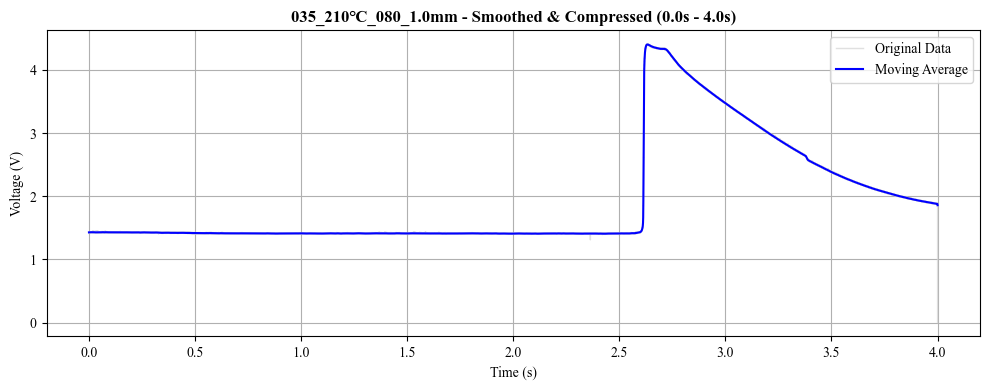

In [5]:
# セル5: 結果の出力（CSV & グラフ）
if not 'df_clipped' in locals() or not 'df_compressed' in locals():
    print("エラー: セル4のデータ処理を先に完了させてください。")
elif len(df_clipped) > 0:
    output_dir = os.path.dirname(filepath)
    base_name = os.path.basename(filepath).replace('.csv', '')
    
    # CSV出力（時間列と隣接平均後の電圧列のみ出力）
    csv_out_path = os.path.join(output_dir, f"{base_name}_smoothed_10k.csv")
    output_df = df_compressed[['Time (s)', smoothed_col_name]]
    output_df.to_csv(csv_out_path, index=False, encoding='utf-8-sig')
    print(f"★ 指定時間範囲・約1万行の圧縮済みデータを出力しました: {csv_out_path}")
    
    # グラフの作成と保存
    print("グラフを描画中...")
    fig, ax = plt.subplots(figsize=(10, 4))
    
    if PLOT_ORIGINAL:
        # 切り抜かれた範囲内の全データ（df_clipped）を使ってグレーの線を描画（ノイズ幅を100%正確に維持）
        ax.plot(df_clipped['Time (s)'], df_clipped[TARGET_COLUMN], color='lightgray', alpha=0.7, linewidth=1.0, label='Original Data')
        
    # 青線は間引き後のデータ（df_compressed）でサクサク描画
    ax.plot(df_compressed['Time (s)'], df_compressed[smoothed_col_name], color='blue', linewidth=1.5, label='Moving Average')
    
    ax.set_title(f"{base_name} - Smoothed & Compressed ({start_t}s - {end_t}s)", fontsize=12, fontweight='bold')
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Voltage (V)")
    ax.legend(loc='upper right')
    ax.grid(True)
    fig.tight_layout()
    
    img_out_path = os.path.join(output_dir, f"{base_name}_smoothed_10k_graph.png")
    fig.savefig(img_out_path, dpi=150)
    print(f"★ グラフ画像を出力しました: {img_out_path}")
    
    plt.show()

吉祥寺全裸マラソン